In [1]:
from sympy import *
init_printing()

In [2]:
#define symbol
# -------------------- # 1. Define symbols # -------------------
Sh, Eh, Ih, Rh, Sm, Em, Im, P_smc = symbols('S_h,E_h,I_h,R_h,S_m,E_m,I_m,P_smc')
# ------------------------------------------------- # 1. Define symbols # --------------
a, beta_h, beta_m, omega_h, mu_h, sigma_h = symbols('a, beta_h, beta_m, omega_h, mu_h, sigma_h')
gamma_h, phi, kappa, eta_A, delta_h = symbols('gamma_h, phi, kappa, eta_A delta_h')
a, eps_LLIN, beta_h, beta_m, Nh = symbols('a eps_LLIN beta_h beta_m N_h')
mu_m, delta_IRS, delta_LLIN, sigma_m = symbols( 'mu_m delta_IRS delta_LLIN sigma_m')
Lambda_h, Lambda_m, delta_L, mu_A, Nm = symbols('Lambda_h Lambda_m delta_L mu_A N_m')
varepsilon_LLIN, xi_smc, theta_smc = symbols('varepsilon_LLIN xi_smc theta_smc')

In [3]:
# ----------------- BASIC REPRODUCTION NUMBER -----------------------------
# Force of infection (λ)
lambda_h = a * beta_h* Im/Nh
lambda_m = a * beta_m * Ih/Nh

# d/dt equations
dSh_dt  = Lambda_h + omega_h*Rh - lambda_h *Sh - mu_h*Sh
dP_smcdt = theta_smc * Sh - (xi_smc + mu_h) * P_smc
dEh_dt  = lambda_h *Sh - (sigma_h + mu_h) * Eh

dIh_dt  = sigma_h * Eh - (delta_h + mu_h + gamma_h) * Ih

dRh_dt  = gamma_h * Ih - (omega_h + mu_h) * Rh


dSm_dt = Lambda_m - lambda_m * Sm - mu_m  * Sm

dEm_dt = lambda_m * Sm - (mu_m + sigma_m) * Em

dIm_dt = sigma_m * Em - mu_m * Im


In [4]:
# At DFE, Force of Infection is given by

f1 = a * beta_h * Im *  Sh / Nh
f2 = 0
f3 = a * beta_m * Ih *  Sm / Nh
f4 = 0

In [5]:
# V matrix represents the rates of transfer out of the infected compartments (E and I)
F = Matrix([f1,f2,f3, f4]).jacobian([Eh, Ih,Em,Im])
F

⎡               Sₕ⋅a⋅βₕ⎤
⎢0     0     0  ───────⎥
⎢                  Nₕ  ⎥
⎢                      ⎥
⎢0     0     0     0   ⎥
⎢                      ⎥
⎢   Sₘ⋅a⋅βₘ            ⎥
⎢0  ───────  0     0   ⎥
⎢      Nₕ              ⎥
⎢                      ⎥
⎣0     0     0     0   ⎦

In [6]:
# AT Disease free equilibrium
Sh_DFE = symbols("S_h^{0}")
Nh_DFE = symbols("N_h^{0}")
Sm_DFE = symbols("S_m^{0}")
Nm_DFE = symbols("N_m^{0}")
F = F.subs(Sh, Sh_DFE)
F = F.subs(Nh, Nh_DFE)
F = F.subs(Sm,Sm_DFE )

F

⎡                     S_h__{0}⋅a⋅βₕ⎤
⎢0        0        0  ─────────────⎥
⎢                        N_h__{0}  ⎥
⎢                                  ⎥
⎢0        0        0        0      ⎥
⎢                                  ⎥
⎢   S_m__{0}⋅a⋅βₘ                  ⎥
⎢0  ─────────────  0        0      ⎥
⎢      N_h__{0}                    ⎥
⎢                                  ⎥
⎣0        0        0        0      ⎦

In [7]:
latex(F)

'\\left[\\begin{matrix}0 & 0 & 0 & \\frac{S_h^{0} a \\beta_{h}}{N_h^{0}}\\\\0 & 0 & 0 & 0\\\\0 & \\frac{S_m^{0} a \\beta_{m}}{N_h^{0}} & 0 & 0\\\\0 & 0 & 0 & 0\\end{matrix}\\right]'

In [8]:
v1 = (mu_h + sigma_h) * Eh
v2 = (mu_h + gamma_h + delta_h) * Ih - sigma_h * Eh
v3 = (mu_m + sigma_m) * Em
v4 = mu_m * Im - sigma_m * Em

In [9]:
# V matrix represents the rates of transfer out of the infected compartments (E and I)
V = Matrix([v1,v2,v3, v4]).jacobian([Eh, Ih,Em,Im])
V

⎡μₕ + σₕ       0           0     0 ⎤
⎢                                  ⎥
⎢  -σₕ    δₕ + γₕ + μₕ     0     0 ⎥
⎢                                  ⎥
⎢   0          0        μₘ + σₘ  0 ⎥
⎢                                  ⎥
⎣   0          0          -σₘ    μₘ⎦

In [10]:
latex(V)

'\\left[\\begin{matrix}\\mu_{h} + \\sigma_{h} & 0 & 0 & 0\\\\- \\sigma_{h} & \\delta_{h} + \\gamma_{h} + \\mu_{h} & 0 & 0\\\\0 & 0 & \\mu_{m} + \\sigma_{m} & 0\\\\0 & 0 & - \\sigma_{m} & \\mu_{m}\\end{matrix}\\right]'

In [11]:
V_inv = V.inv()
V_inv

⎡                     1                                                    ⎤
⎢                  ───────                         0             0       0 ⎥
⎢                  μₕ + σₕ                                                 ⎥
⎢                                                                          ⎥
⎢                     σₕ                           1                       ⎥
⎢───────────────────────────────────────────  ────────────       0       0 ⎥
⎢                                  2          δₕ + γₕ + μₕ                 ⎥
⎢δₕ⋅μₕ + δₕ⋅σₕ + γₕ⋅μₕ + γₕ⋅σₕ + μₕ  + μₕ⋅σₕ                               ⎥
⎢                                                                          ⎥
⎢                                                                1         ⎥
⎢                     0                            0          ───────    0 ⎥
⎢                                                             μₘ + σₘ      ⎥
⎢                                                                          ⎥

In [12]:
# Calculate the Next Generation Matrix (NGM)
NGM = F * V_inv
NGM

⎡                                                                             
⎢                          0                                        0         
⎢                                                                             
⎢                                                                             
⎢                                                                             
⎢                          0                                        0         
⎢                                                                             
⎢                   S_m__{0}⋅a⋅βₘ⋅σₕ                          S_m__{0}⋅a⋅βₘ   
⎢──────────────────────────────────────────────────────  ─────────────────────
⎢         ⎛                                  2        ⎞  N_h__{0}⋅(δₕ + γₕ + μ
⎢N_h__{0}⋅⎝δₕ⋅μₕ + δₕ⋅σₕ + γₕ⋅μₕ + γₕ⋅σₕ + μₕ  + μₕ⋅σₕ⎠                       
⎢                                                                             
⎣                          0                        

In [13]:
latex(NGM)

'\\left[\\begin{matrix}0 & 0 & \\frac{S_h^{0} a \\beta_{h} \\sigma_{m}}{N_h^{0} \\left(\\mu_{m}^{2} + \\mu_{m} \\sigma_{m}\\right)} & \\frac{S_h^{0} a \\beta_{h}}{N_h^{0} \\mu_{m}}\\\\0 & 0 & 0 & 0\\\\\\frac{S_m^{0} a \\beta_{m} \\sigma_{h}}{N_h^{0} \\left(\\delta_{h} \\mu_{h} + \\delta_{h} \\sigma_{h} + \\gamma_{h} \\mu_{h} + \\gamma_{h} \\sigma_{h} + \\mu_{h}^{2} + \\mu_{h} \\sigma_{h}\\right)} & \\frac{S_m^{0} a \\beta_{m}}{N_h^{0} \\left(\\delta_{h} + \\gamma_{h} + \\mu_{h}\\right)} & 0 & 0\\\\0 & 0 & 0 & 0\\end{matrix}\\right]'

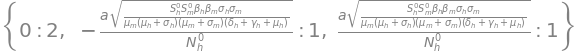

In [14]:
eigenvalues=NGM.eigenvals()
eigenvalues

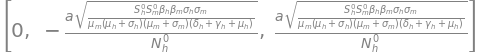

In [15]:
R0_list= list (eigenvalues.keys())
R0_list

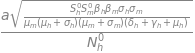

In [16]:
R0 = R0_list[2]
R0

In [17]:
latex(R0)

'\\frac{a \\sqrt{\\frac{S_h^{0} S_m^{0} \\beta_{h} \\beta_{m} \\sigma_{h} \\sigma_{m}}{\\mu_{m} \\left(\\mu_{h} + \\sigma_{h}\\right) \\left(\\mu_{m} + \\sigma_{m}\\right) \\left(\\delta_{h} + \\gamma_{h} + \\mu_{h}\\right)}}}{N_h^{0}}'

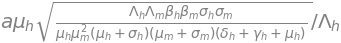

In [18]:
R0 = R0.subs(Nh_DFE, Lambda_h/mu_h)
R0 = R0.subs(Sm_DFE, Lambda_m/mu_m)
R0 = R0.subs(Sh_DFE, Lambda_h/mu_h)
simplify(R0)

In [19]:
latex(R0)

'\\frac{a \\mu_{h} \\sqrt{\\frac{\\Lambda_{h} \\Lambda_{m} \\beta_{h} \\beta_{m} \\sigma_{h} \\sigma_{m}}{\\mu_{h} \\mu_{m}^{2} \\left(\\mu_{h} + \\sigma_{h}\\right) \\left(\\mu_{m} + \\sigma_{m}\\right) \\left(\\delta_{h} + \\gamma_{h} + \\mu_{h}\\right)}}}{\\Lambda_{h}}'

In [20]:
# ----------------- Control REPRODUCTION NUMBER -----------------------------
delta_EMS = symbols('delta_EMS')
mu_c = symbols("mu_m^c")
 # mu_c = mu_m + delta_IRS + delta_LLIN + delta_EMS
# Force of infection (λ)
lambda_h = a * beta_h* Im/Nh
lambda_m = a * beta_m * Ih/Nh

# d/dt equations
dSh_dt  = Lambda_h + omega_h*Rh +  xi_smc * P_smc- lambda_h *Sh - (mu_h + theta_smc) * Sh
dP_smcdt = theta_smc * Sh - (xi_smc + mu_h) * P_smc


dEh_dt  = lambda_h *Sh - (sigma_h + mu_h) * Eh

dIh_dt  = sigma_h * Eh - (delta_h + mu_h + gamma_h) * Ih

dRh_dt  = gamma_h * Ih - (omega_h + mu_h) * Rh


dSm_dt = (1 - delta_L - delta_EMS) * Lambda_m - lambda_m * Sm - mu_c * Sm

dEm_dt = lambda_m * Sm - (mu_c + sigma_m) * Em

dIm_dt = sigma_m * Em - mu_c * Im

In [21]:
# At DFE, Force of Infection is given by
# lets ch = ( 1 - varepsilon_LLIN) * a * beta_h
# lets cm = ( 1 - varepsilon_LLIN) * a * beta_m
ch = symbols('c_h')
cm = symbols('c_m')
# Force of infection (λ)

f1_c = ch * Im *  Sh / Nh
f2_c = 0
f3_c = cm * Ih *  Sm / Nh
f4_c = 0

In [22]:
# V matrix represents the rates of transfer out of the infected compartments (E and I)
F_c = Matrix([f1_c,f2_c,f3_c, f4_c]).jacobian([Eh, Ih,Em,Im])
F_c


⎡             Sₕ⋅cₕ⎤
⎢0    0    0  ─────⎥
⎢               Nₕ ⎥
⎢                  ⎥
⎢0    0    0    0  ⎥
⎢                  ⎥
⎢   Sₘ⋅cₘ          ⎥
⎢0  ─────  0    0  ⎥
⎢     Nₕ           ⎥
⎢                  ⎥
⎣0    0    0    0  ⎦

In [23]:
# AT Disease free equilibrium
Shc_DFE = symbols("S_{hc}^{0}")
Nhc_DFE = symbols("N_{hc}^{0}")
Smc_DFE = symbols("S_{mc}^{0}")
Nmc_DFE = symbols("N_{mc}^{0}")
F_c = F_c.subs(Sh, Shc_DFE)
F_c = F_c.subs(Nh, Nhc_DFE)
F_c = F_c.subs(Sm,Smc_DFE )

F_c

⎡                      S_{hc}__{0}⋅cₕ⎤
⎢0        0         0  ──────────────⎥
⎢                       N_{hc}__{0}  ⎥
⎢                                    ⎥
⎢0        0         0        0       ⎥
⎢                                    ⎥
⎢   S_{mc}__{0}⋅cₘ                   ⎥
⎢0  ──────────────  0        0       ⎥
⎢    N_{hc}__{0}                     ⎥
⎢                                    ⎥
⎣0        0         0        0       ⎦

In [24]:
latex(F_c)

'\\left[\\begin{matrix}0 & 0 & 0 & \\frac{S_{hc}^{0} c_{h}}{N_{hc}^{0}}\\\\0 & 0 & 0 & 0\\\\0 & \\frac{S_{mc}^{0} c_{m}}{N_{hc}^{0}} & 0 & 0\\\\0 & 0 & 0 & 0\\end{matrix}\\right]'

In [25]:
v1_c = (mu_h + sigma_h) * Eh
v2_c = (mu_h + gamma_h + delta_h) * Ih - sigma_h * Eh
v3_c = (mu_c + sigma_m) * Em
v4_c = mu_c * Im - sigma_m * Em

In [26]:
# V matrix represents the rates of transfer out of the infected compartments (E and I)
V_c = Matrix([v1_c,v2_c,v3_c, v4_c]).jacobian([Eh, Ih,Em,Im])
V_c

⎡μₕ + σₕ       0             0         0   ⎤
⎢                                          ⎥
⎢  -σₕ    δₕ + γₕ + μₕ       0         0   ⎥
⎢                                          ⎥
⎢   0          0        μ_m__c + σₘ    0   ⎥
⎢                                          ⎥
⎣   0          0            -σₘ      μ_m__c⎦

In [27]:
latex(V_c)

'\\left[\\begin{matrix}\\mu_{h} + \\sigma_{h} & 0 & 0 & 0\\\\- \\sigma_{h} & \\delta_{h} + \\gamma_{h} + \\mu_{h} & 0 & 0\\\\0 & 0 & \\mu^{c}_{m} + \\sigma_{m} & 0\\\\0 & 0 & - \\sigma_{m} & \\mu^{c}_{m}\\end{matrix}\\right]'

In [28]:
V_inv_c = V_c.inv()
V_inv_c

⎡                     1                                                       
⎢                  ───────                         0                 0        
⎢                  μₕ + σₕ                                                    
⎢                                                                             
⎢                     σₕ                           1                          
⎢───────────────────────────────────────────  ────────────           0        
⎢                                  2          δₕ + γₕ + μₕ                    
⎢δₕ⋅μₕ + δₕ⋅σₕ + γₕ⋅μₕ + γₕ⋅σₕ + μₕ  + μₕ⋅σₕ                                  
⎢                                                                             
⎢                                                                    1        
⎢                     0                            0            ───────────   
⎢                                                               μ_m__c + σₘ   
⎢                                                   

In [29]:
# Calculate the Next Generation Matrix (NGM)
NGM_c = F_c * V_inv_c
NGM_c

⎡                                                                             
⎢                            0                                          0     
⎢                                                                             
⎢                                                                             
⎢                                                                             
⎢                            0                                          0     
⎢                                                                             
⎢                    S_{mc}__{0}⋅cₘ⋅σₕ                            S_{mc}__{0}⋅
⎢─────────────────────────────────────────────────────────  ──────────────────
⎢            ⎛                                  2        ⎞  N_{hc}__{0}⋅(δₕ + 
⎢N_{hc}__{0}⋅⎝δₕ⋅μₕ + δₕ⋅σₕ + γₕ⋅μₕ + γₕ⋅σₕ + μₕ  + μₕ⋅σₕ⎠                    
⎢                                                                             
⎣                            0                      

In [30]:
latex(NGM_c)

'\\left[\\begin{matrix}0 & 0 & \\frac{S_{hc}^{0} c_{h} \\sigma_{m}}{N_{hc}^{0} \\left(\\left(\\mu^{c}_{m}\\right)^{2} + \\mu^{c}_{m} \\sigma_{m}\\right)} & \\frac{S_{hc}^{0} c_{h}}{N_{hc}^{0} \\mu^{c}_{m}}\\\\0 & 0 & 0 & 0\\\\\\frac{S_{mc}^{0} c_{m} \\sigma_{h}}{N_{hc}^{0} \\left(\\delta_{h} \\mu_{h} + \\delta_{h} \\sigma_{h} + \\gamma_{h} \\mu_{h} + \\gamma_{h} \\sigma_{h} + \\mu_{h}^{2} + \\mu_{h} \\sigma_{h}\\right)} & \\frac{S_{mc}^{0} c_{m}}{N_{hc}^{0} \\left(\\delta_{h} + \\gamma_{h} + \\mu_{h}\\right)} & 0 & 0\\\\0 & 0 & 0 & 0\\end{matrix}\\right]'

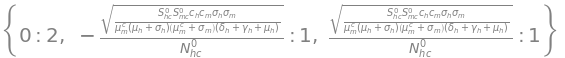

In [31]:
eigenvalues_c=NGM_c.eigenvals()
eigenvalues_c

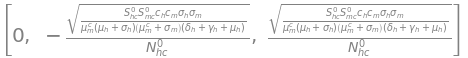

In [32]:
R0_c_list= list (eigenvalues_c.keys())
R0_c_list

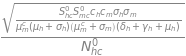

In [33]:
R0_c = R0_c_list[2]
R0_c

## Disease Free Equilibrium for Control

In [34]:
# ----------------- Control REPRODUCTION NUMBER -----------------------------
delta_EMS = symbols('delta_EMS')
mu_c = symbols("mu_m^c")
 # mu_c = mu_m + delta_IRS + delta_LLIN + delta_EMS
# Force of infection (λ)
lambda_h = a * beta_h* Im/Nh
lambda_m = a * beta_m * Ih/Nh

# d/dt equations
dSh_dt  = Lambda_h + omega_h*Rh +  xi_smc * P_smc- lambda_h *Sh - (mu_h + theta_smc) * Sh
dP_smcdt = theta_smc * Sh - (xi_smc + mu_h) * P_smc


dEh_dt  = lambda_h *Sh - (sigma_h + mu_h) * Eh

dIh_dt  = sigma_h * Eh - (delta_h + mu_h + gamma_h) * Ih

dRh_dt  = gamma_h * Ih - (omega_h + mu_h) * Rh


dSm_dt = (1 - delta_L - delta_EMS) * Lambda_m - lambda_m * Sm - mu_c * Sm

dEm_dt = lambda_m * Sm - (mu_c + sigma_m) * Em

dIm_dt = sigma_m * Em - mu_c * Im

In [35]:
#setup the system of equation
equations = [
    Eq(dSh_dt.subs({Eh:0,Ih:0,Em:0,Im:0}),0),
    Eq(dEh_dt.subs({Eh:0,Ih:0,Em:0,Im:0}),0),
    Eq(dIh_dt.subs({Eh:0,Ih:0,Em:0,Im:0}),0),
    Eq(dP_smcdt.subs({Eh:0,Ih:0,Em:0,Im:0}),0),
    Eq(dRh_dt.subs({Eh:0,Ih:0,Em:0,Im:0}),0),
    Eq(dSm_dt.subs({Eh:0,Ih:0,Em:0,Im:0}),0),
    Eq(dEm_dt.subs({Eh:0,Ih:0,Em:0,Im:0}),0),
    Eq(dIm_dt.subs({Eh:0,Ih:0,Em:0,Im:0}),0),

]

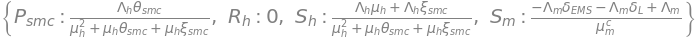

In [36]:
Equilibrium_solution=solve(equations,[Sh,Eh,Ih,Rh,P_smc,Sm,Em,Im])
Equilibrium_solution

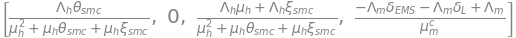

In [37]:
values = list(Equilibrium_solution.values())
values

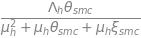

In [38]:
P_smc_DFE = values[0]
P_smc_DFE

In [39]:
Rh_DFE = values[1]
Rh_DFE

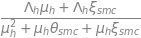

In [40]:
Sh_DFE = values[2]
Sh_DFE

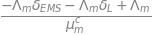

In [41]:
Sm_DFE = values[3]
Sm_DFE

In [42]:
Nh_DFE = Sh_DFE + P_smc_DFE
Nh_DFE_sim = simplify(Nh_DFE)
Nh_DFE_sim

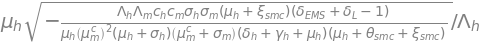

In [43]:
R0_c = R0_c.subs(Nhc_DFE, Nh_DFE_sim)
R0_c = R0_c.subs(Smc_DFE, Sm_DFE)
R0_c = R0_c.subs(Shc_DFE, Sh_DFE)
R0_c = simplify(R0_c)
R0_c


In [44]:
latex(R0_c)

'\\frac{\\mu_{h} \\sqrt{- \\frac{\\Lambda_{h} \\Lambda_{m} c_{h} c_{m} \\sigma_{h} \\sigma_{m} \\left(\\mu_{h} + \\xi_{smc}\\right) \\left(\\delta_{EMS} + \\delta_{L} - 1\\right)}{\\mu_{h} \\left(\\mu^{c}_{m}\\right)^{2} \\left(\\mu_{h} + \\sigma_{h}\\right) \\left(\\mu^{c}_{m} + \\sigma_{m}\\right) \\left(\\delta_{h} + \\gamma_{h} + \\mu_{h}\\right) \\left(\\mu_{h} + \\theta_{smc} + \\xi_{smc}\\right)}}}{\\Lambda_{h}}'

In [45]:
k1, k2,m = symbols('k_1 k_2 m')

In [46]:
V = V.subs(mu_h + sigma_h, k1)
V = V.subs(mu_h + gamma_h + delta_h, k2)
V = V.subs(mu_m + delta_IRS + delta_LLIN, m)

In [47]:
V

⎡k₁   0      0     0 ⎤
⎢                    ⎥
⎢-σₕ  k₂     0     0 ⎥
⎢                    ⎥
⎢ 0   0   μₘ + σₘ  0 ⎥
⎢                    ⎥
⎣ 0   0     -σₘ    μₘ⎦

In [48]:
latex(V)

'\\left[\\begin{matrix}k_{1} & 0 & 0 & 0\\\\- \\sigma_{h} & k_{2} & 0 & 0\\\\0 & 0 & \\mu_{m} + \\sigma_{m} & 0\\\\0 & 0 & - \\sigma_{m} & \\mu_{m}\\end{matrix}\\right]'

In [49]:
# Calculate the Next Generation Matrix (NGM)
NGM = F * V.inv()
NGM

⎡                                    S_h__{0}⋅a⋅βₕ⋅σₘ     S_h__{0}⋅a⋅βₕ⎤
⎢       0                0        ──────────────────────  ─────────────⎥
⎢                                          ⎛  2        ⎞   N_h__{0}⋅μₘ ⎥
⎢                                 N_h__{0}⋅⎝μₘ  + μₘ⋅σₘ⎠               ⎥
⎢                                                                      ⎥
⎢       0                0                  0                   0      ⎥
⎢                                                                      ⎥
⎢S_m__{0}⋅a⋅βₘ⋅σₕ  S_m__{0}⋅a⋅βₘ                                       ⎥
⎢────────────────  ─────────────            0                   0      ⎥
⎢ N_h__{0}⋅k₁⋅k₂    N_h__{0}⋅k₂                                        ⎥
⎢                                                                      ⎥
⎣       0                0                  0                   0      ⎦

In [50]:
latex(NGM)

'\\left[\\begin{matrix}0 & 0 & \\frac{S_h^{0} a \\beta_{h} \\sigma_{m}}{N_h^{0} \\left(\\mu_{m}^{2} + \\mu_{m} \\sigma_{m}\\right)} & \\frac{S_h^{0} a \\beta_{h}}{N_h^{0} \\mu_{m}}\\\\0 & 0 & 0 & 0\\\\\\frac{S_m^{0} a \\beta_{m} \\sigma_{h}}{N_h^{0} k_{1} k_{2}} & \\frac{S_m^{0} a \\beta_{m}}{N_h^{0} k_{2}} & 0 & 0\\\\0 & 0 & 0 & 0\\end{matrix}\\right]'

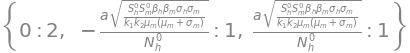

In [51]:
eigenvalues=NGM.eigenvals()
eigenvalues

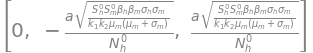

In [56]:
R0= list (eigenvalues.keys())
R0

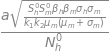

In [57]:
R0 = R0[2]
R0

In [58]:
mm = (kappa * eta_A/m)*(1 - m * (eta_A + mu_A + delta_L)/(eta_A * phi))
mm

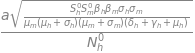

In [59]:

R0 = R0.subs(k1, mu_h + sigma_h)
R0 = R0.subs(k2, mu_h + gamma_h + delta_h)
R0 = R0.subs(Nh_DFE, Lambda_h/mu_h)
R0 = R0.subs(Sm_DFE, (kappa * eta_A/m)*(1 - m * (eta_A + mu_A + delta_L)/(eta_A * phi)))
R0 = R0.subs(ch, a * (1 - varepsilon_LLIN) * beta_h)
R0 = R0.subs(cm, a * (1 - varepsilon_LLIN) * beta_m)

R0

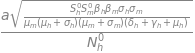

In [60]:
R0 = R0.simplify()
R0

In [61]:
latex(R0)

'\\frac{a \\sqrt{\\frac{S_h^{0} S_m^{0} \\beta_{h} \\beta_{m} \\sigma_{h} \\sigma_{m}}{\\mu_{m} \\left(\\mu_{h} + \\sigma_{h}\\right) \\left(\\mu_{m} + \\sigma_{m}\\right) \\left(\\delta_{h} + \\gamma_{h} + \\mu_{h}\\right)}}}{N_h^{0}}'